In [1]:
import gym
import cityflow
import gym_cityflow
import numpy as np
import matplotlib.pyplot as plt
import torch
import random
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [2]:
env = gym.make(
    id='cityflow-v0',
    configPath='Intersections_1/sample_config_2.json',
    episodeSteps=1000
)

In [3]:
print("Observation Space: ", env.observation_space)
print("Action Space: ", env.action_space)

Observation Space:  Dict('intersection_1_1': MultiDiscrete([[827 827]
 [827 827]
 [827 827]
 [827 827]
 [827 827]
 [827 827]
 [827 827]
 [827 827]
 [827 827]
 [827 827]
 [827 827]
 [827 827]
 [827 827]
 [827 827]
 [827 827]
 [827 827]]))
Action Space:  MultiDiscrete([9])


In [4]:
class DQN_network(nn.Module):
    def __init__(self):
        super(DQN_network, self).__init__()
        self.fc_hidden_1 = nn.Linear(32, 128)
        self.fc_hidden_2 = nn.Linear(128, 64)
        self.fc_out = nn.Linear(64, 9)

    def forward(self, x):
        x = torch.relu(self.fc_hidden_1(x))
        x = torch.relu(self.fc_hidden_2(x))
        x = self.fc_out(x)
        return x

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [6]:
dqn_net = DQN_network()
target_net = DQN_network()
init_dqn_net = dqn_net.state_dict()
target_net.load_state_dict(init_dqn_net)
target_net.eval()
dqn_net.to(device)
target_net.to(device)

DQN_network(
  (fc_hidden_1): Linear(in_features=32, out_features=128, bias=True)
  (fc_hidden_2): Linear(in_features=128, out_features=64, bias=True)
  (fc_out): Linear(in_features=64, out_features=9, bias=True)
)

In [7]:
class Replay_Buffer:
    def __init__(self):
        self.max_size = 10000
        self.idx = 0
        self.size = 0
        self.states = np.zeros((self.max_size, 32), dtype=np.float32)
        self.actions = np.zeros(self.max_size, dtype=np.int64)
        self.next_states = np.zeros((self.max_size, 32), dtype=np.float32)
        self.rewards = np.zeros(self.max_size, dtype=np.float32)
        self.dones = np.zeros(self.max_size, dtype=np.float32)

    def store(self, state, action, next_state, reward, done):
        self.states[self.idx] = state
        self.actions[self.idx] = action
        self.next_states[self.idx] = next_state
        self.rewards[self.idx] = reward
        self.dones[self.idx] = done

        if self.idx + 1 >= self.max_size:
            self.idx = 0
        else:
            self.idx += 1
            
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batch_size):
        idxs = np.random.randint(0, self.size, batch_size)
        return (self.states[idxs], self.actions[idxs], self.next_states[idxs], self.rewards[idxs], self.dones[idxs])

    def __len__(self):
        return self.size

In [8]:
def epsilon_greedy(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()
    else:
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        q_values = dqn_net(state)
        return torch.argmax(q_values).item()

In [9]:
num_episodes = 2000
batch_size = 128
gamma = 0.8
epsilon = 1.0
epsilon_min = 0.001
epsilon_decay = 0.999
lr = 1e-4
train_freq = 4
target_dqn_update_freq = 8

optimizer = optim.Adam(dqn_net.parameters(), lr=lr)
replay_buffer = Replay_Buffer()

/user/gaganvad/.local/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:174: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.warn(
/user/gaganvad/.local/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:187: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.warn(
/user/gaganvad/.local/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `<class 'dict'>`
  logger.warn(
/user/gaganvad/.local/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:219: DeprecationWarning: WARN: Core env

Episode 0, Total Reward: -2186.00, Epsilon: 0.999
Episode 1, Total Reward: -2123.00, Epsilon: 0.998
Episode 2, Total Reward: -2596.00, Epsilon: 0.997
Episode 3, Total Reward: -1733.00, Epsilon: 0.996
Episode 4, Total Reward: -762.00, Epsilon: 0.995
Episode 5, Total Reward: -1568.00, Epsilon: 0.994
Episode 6, Total Reward: -7132.00, Epsilon: 0.993
Episode 7, Total Reward: -908.00, Epsilon: 0.992
Episode 8, Total Reward: -4712.00, Epsilon: 0.991
Episode 9, Total Reward: -3239.00, Epsilon: 0.990
Episode 10, Total Reward: -1604.00, Epsilon: 0.989
Episode 11, Total Reward: -1114.00, Epsilon: 0.988
Episode 12, Total Reward: -1601.00, Epsilon: 0.987
Episode 13, Total Reward: -1789.00, Epsilon: 0.986
Episode 14, Total Reward: -3100.00, Epsilon: 0.985
Episode 15, Total Reward: -1971.00, Epsilon: 0.984
Episode 16, Total Reward: -1303.00, Epsilon: 0.983
Episode 17, Total Reward: -927.00, Epsilon: 0.982
Episode 18, Total Reward: -1434.00, Epsilon: 0.981
Episode 19, Total Reward: -487.00, Epsilon: 

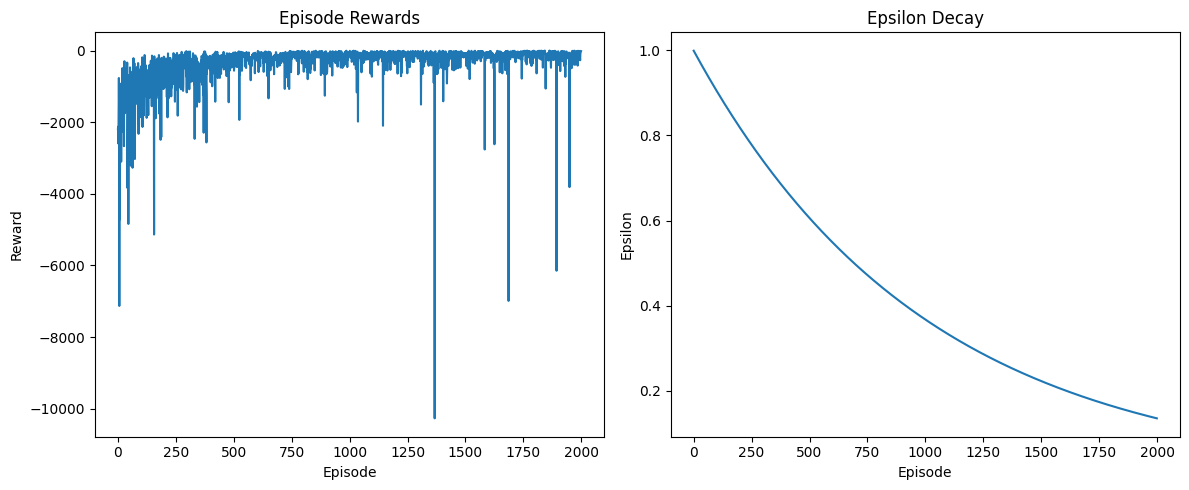

In [10]:
cnt_step = 0
episode_rewards = []
epsilon_values = []

for episode in range(num_episodes):
    state = env.reset()
    state = np.array(state['intersection_1_1'], dtype=np.float32).flatten()
    done = False
    total_reward = 0

    while not done:
        action = epsilon_greedy(state, epsilon)
        #print(action)
        next_state, rewards, done, _ = env.step([action])

        next_state = np.array(next_state['intersection_1_1'], dtype=np.float32).flatten()
        reward = rewards[0][1]

        total_reward += reward
        
        replay_buffer.store(state, action, next_state, reward, float(done))
        state = next_state
        cnt_step += 1
        
        if len(replay_buffer) >= batch_size and cnt_step % train_freq == 0:
            states, actions, next_states, rewards, dones = replay_buffer.sample(batch_size)

            states = torch.tensor(states, dtype=torch.float32)
            actions = torch.tensor(actions, dtype=torch.long).unsqueeze(1)
            next_states = torch.tensor(next_states, dtype=torch.float32)
            rewards = torch.tensor(rewards, dtype=torch.float32)
            dones = torch.tensor(dones, dtype=torch.float32)

            q_values_curr_state = dqn_net(states)
            q_values_curr_state_action = q_values_curr_state.gather(1, actions).squeeze(1)
            with torch.no_grad():
                q_values_next_state = target_net(next_states)
                q_value_next_state_best_action = q_values_next_state.max(dim=1)[0]
            target_q_values = rewards + gamma * q_value_next_state_best_action * (1-dones)

            loss = F.mse_loss(q_values_curr_state_action, target_q_values)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if (episode+1) % target_dqn_update_freq == 0:
        target_net.load_state_dict(dqn_net.state_dict())

    episode_rewards.append(total_reward)
    epsilon_values.append(epsilon)

    if len(episode_rewards) >= 10:
        avg_reward = np.mean(episode_rewards[-10:])
        if avg_reward > 470:
            print(f"Early Stopping at Episode {episode} with average reward {avg_reward:.2f} over last 10 episodes")
            break

    print(f"Episode {episode}, Total Reward: {total_reward:.2f}, Epsilon: {epsilon:.3f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(episode_rewards)
plt.title("Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")

plt.subplot(1, 2, 2)
plt.plot(epsilon_values)
plt.title("Epsilon Decay")
plt.xlabel("Episode")
plt.ylabel("Epsilon")

plt.tight_layout()
plt.show()